# 07. Avaliação de Modelos e Incerteza: Reamostragem na Regressão Logística

**Objetivo da Etapa:**
1. **Validação Cruzada K-Fold (K = 5):** Estimar capacidade preditiva (Acurácia, Precisão, Recall e Especificidade).
2. **Bootstrap (B = 2000):** Avaliar a distribuição e incerteza do coeficiente logístico e do Odds Ratio.

In [1]:
library(readr)
library(dplyr)
library(ggplot2)
library(scales)
library(fs)

options(scipen = 999, digits = 4)
set.seed(123)

caminho_csv <- path(getwd(), "data", "processed", "df_sazonal_lideres.csv")
if (!file_exists(caminho_csv)) {
  caminho_csv <- path(path_dir(getwd()), "data", "processed", "df_sazonal_lideres.csv")
}
dados <- read_csv2(caminho_csv, show_col_types = FALSE)

# Identifica dinamicamente a coluna do peso (com espaço ou underline)
col_peso <- grep("Quilograma", names(dados), value = TRUE)[1]

dados_logistica <- dados %>%
  mutate(
    Fluxo_bin = ifelse(grepl("Exp", as.character(Fluxo), ignore.case = TRUE), 1L, 0L),
    Quilograma_Liquido_Escalado = .data[[col_peso]] / 1000000
  ) %>%
  filter(!is.na(Quilograma_Liquido_Escalado) & !is.na(Fluxo_bin))

n <- nrow(dados_logistica)
cat(sprintf("Base Logística carregada com sucesso: %d observações.\n", n))


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘scales’


The following object is masked from ‘package:readr’:

    col_factor


ℹ Using "','" as decimal and "'.'" as grouping mark. Use `read_delim()` for more control.



Base Logística carregada com sucesso: 481 observações.


## 1. Validação Cruzada 5-Fold na Regressão Logística

In [2]:
fórmula_logistica <- Fluxo_bin ~ Quilograma_Liquido_Escalado

calcular_metricas <- function(y_real, p_pred, limiar = 0.5) {
  y_pred <- ifelse(p_pred >= limiar, 1L, 0L)
  acuracia <- mean(y_real == y_pred)
  tp <- sum(y_real == 1 & y_pred == 1)
  fp <- sum(y_real == 0 & y_pred == 1)
  fn <- sum(y_real == 1 & y_pred == 0)
  tn <- sum(y_real == 0 & y_pred == 0)
  precisao <- ifelse((tp + fp) > 0, tp / (tp + fp), 0)
  recall <- ifelse((tp + fn) > 0, tp / (tp + fn), 0)
  especificidade <- ifelse((tn + fp) > 0, tn / (tn + fp), 0)
  return(c(Acuracia = acuracia, Precisao = precisao, Recall = recall, Especificidade = especificidade))
}

K <- 5
folds <- sample(rep(1:K, length.out = n))
metricas_folds <- matrix(0, nrow = K, ncol = 4)
colnames(metricas_folds) <- c("Acuracia", "Precisao", "Recall", "Especificidade")

for (k in 1:K) {
  treino <- dados_logistica[folds != k, ]
  validacao <- dados_logistica[folds == k, ]
  fit_log <- glm(fórmula_logistica, family = binomial(link = "logit"), data = treino)
  prob_pred <- predict(fit_log, newdata = validacao, type = "response")
  metricas_folds[k, ] <- calcular_metricas(validacao$Fluxo_bin, prob_pred)
}

tabela_cv_logistica <- as.data.frame(metricas_folds)
tabela_cv_logistica$Fold <- 1:K
print(tabela_cv_logistica)

  Acuracia Precisao Recall Especificidade Fold
1   0.7010   0.8333 0.5102         0.8958    1
2   0.7708   0.8788 0.6170         0.9184    2
3   0.7292   0.9200 0.4894         0.9592    3
4   0.7188   0.8065 0.5435         0.8800    4
5   0.6667   0.7879 0.5098         0.8444    5


## 2. Quantificação de Incerteza via Bootstrap (B = 2000)

Beta Original: 0.016866 | OR Original: 1.017009
SE Bootstrap: 0.001973
IC 95% Beta: [0.013423, 0.021196]


Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”
Warning message:
“The dot-dot notation (`..density..`) was deprecated in ggplot2 3.4.0.
ℹ Please use `after_stat(density)` instead.”


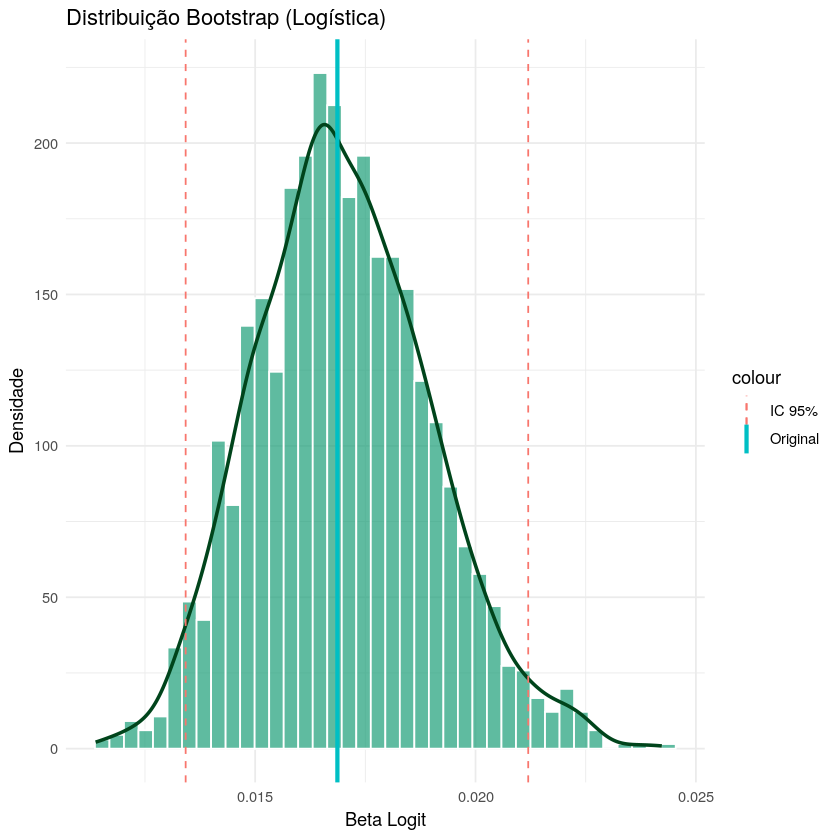

In [3]:
B <- 2000
fit_log_orig <- glm(fórmula_logistica, family = binomial(link = "logit"), data = dados_logistica)
beta_log_orig <- coef(fit_log_orig)["Quilograma_Liquido_Escalado"]
or_orig <- exp(beta_log_orig)

boot_beta_log <- numeric(B)
boot_or_log <- numeric(B)

for (b in 1:B) {
  idx <- sample(1:n, size = n, replace = TRUE)
  fit_boot <- glm(fórmula_logistica, family = binomial(link = "logit"), data = dados_logistica[idx, ])
  beta_val <- coef(fit_boot)["Quilograma_Liquido_Escalado"]
  boot_beta_log[b] <- beta_val
  boot_or_log[b] <- exp(beta_val)
}

se_boot_log <- sd(boot_beta_log)
ci_percentil_beta <- quantile(boot_beta_log, probs = c(0.025, 0.975))
ci_percentil_or <- quantile(boot_or_log, probs = c(0.025, 0.975))

cat(sprintf("Beta Original: %.6f | OR Original: %.6f\n", beta_log_orig, or_orig))
cat(sprintf("SE Bootstrap: %.6f\n", se_boot_log))
cat(sprintf("IC 95%% Beta: [%.6f, %.6f]\n", ci_percentil_beta[1], ci_percentil_beta[2]))

df_boot_log_plot <- data.frame(beta_val = boot_beta_log)
ggplot(df_boot_log_plot, aes(x = beta_val)) +
  geom_histogram(aes(y = ..density..), bins = 40, fill = "#1b9e77", color = "white", alpha = 0.7) +
  geom_density(color = "#00441b", size = 1) +
  geom_vline(aes(xintercept = beta_log_orig, color = "Original"), size = 1.2) +
  geom_vline(aes(xintercept = ci_percentil_beta[1], color = "IC 95%"), linetype = "dashed") +
  geom_vline(aes(xintercept = ci_percentil_beta[2], color = "IC 95%"), linetype = "dashed") +
  labs(title = "Distribuição Bootstrap (Logística)", x = "Beta Logit", y = "Densidade") +
  theme_minimal()